# Explore the new monthly LPJ-GUESS files (FPC & LAI)

**What these files are** (from Jing's ReadMe):
- Monthly *climatology* — 12 rows per grid cell (one per calendar month),
  averaged over the period.
- `mfpc` = foliage projective cover, `mlai` = leaf area index.
- `avg` = monthly-mean (averaged over the month) vs `eom` = end-of-month.
- This file: GFDL-ESM4, SSP5-8.5, **2070-2100** (future only for GFDL).

**Why we care.** The monthly resolution lets us take the *annual maximum*
(peak-season) FPC/LAI instead of the annual mean, which removes the deciduous
seasonal under-read (a summergreen PFT's annual mean is dragged down by its
leafless months; an evergreen's is not).


In [9]:
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
plt.rcParams.update({"font.family": "STIXGeneral", "mathtext.fontset": "stix"})

DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS")
FPC_FUT = DATA / "mfpc_pft_avg_2070_2100_monthly_mean.out"
LAI_FUT = DATA / "mlai_pft_avg_2070_2100_monthly_mean.out"
FPC_HIST = DATA / "mfpc_pft_avg_1971_2000_monthly_mean.out"
LAI_HIST = DATA / "mlai_pft_avg_1971_2000_monthly_mean.out"

LPJ_NATURAL = ["BNE","BINE","BNS","TeNE","TeBE","IBS","TeBS","C3G",
               "HSE","HSS","LSE","LSS","GRT","EPDS","SPDS","CLM"]


## Loader — monthly climatology -> (natpft, month, lat, lon)
The ReadMe warns some files repeat the header mid-table, so we drop any row
whose first field is "Lon" before casting to float.


In [10]:
def load_monthly(path, names=LPJ_NATURAL):
    df = pd.read_csv(path, sep=r"\s+", low_memory=False)
    df = df[df["Lon"] != "Lon"].copy()                 # drop repeated headers
    df[["Lon","Lat","Month"]] = df[["Lon","Lat","Month"]].astype(float)
    df[names] = df[names].astype(float)
    da = (df.set_index(["Month","Lat","Lon"])[names]
            .to_xarray().to_array("natpft"))
    return da.transpose("natpft","Month","Lat","Lon").rename({"Month":"month","Lat":"lat","Lon":"lon"})

fpc_fut = load_monthly(FPC_FUT)     # (natpft, month=12, lat, lon)
lai_fut = load_monthly(LAI_FUT)
fpc_hist = load_monthly(FPC_HIST)     # (natpft, month=12, lat, lon)
lai_hist = load_monthly(LAI_HIST)
print("FPC monthly:", dict(fpc_fut.sizes))
print("months:", fpc_fut.month.values.astype(int))


FPC monthly: {'natpft': 16, 'month': 12, 'lat': 75, 'lon': 638}
months: [ 1  2  3  4  5  6  7  8  9 10 11 12]


## 1 · Seasonal cycle: evergreen vs deciduous
Domain-mean FPC by month. Evergreens should be near-flat; summergreen/tundra
types should peak in summer and fall to ~0 in winter — this is the seasonal
signal the annual mean washes out.


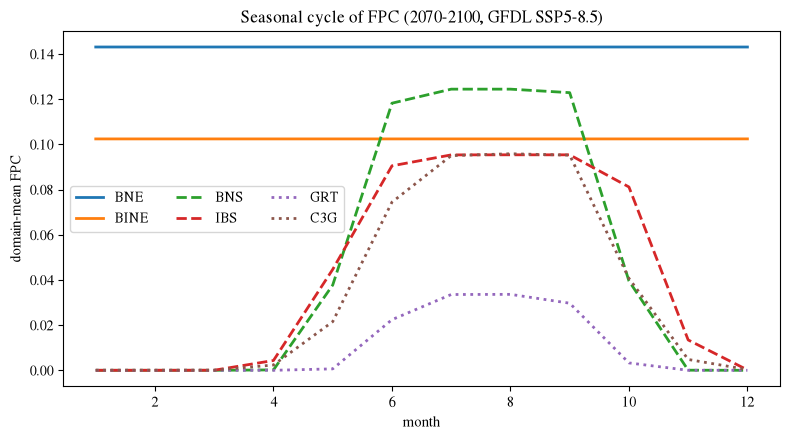

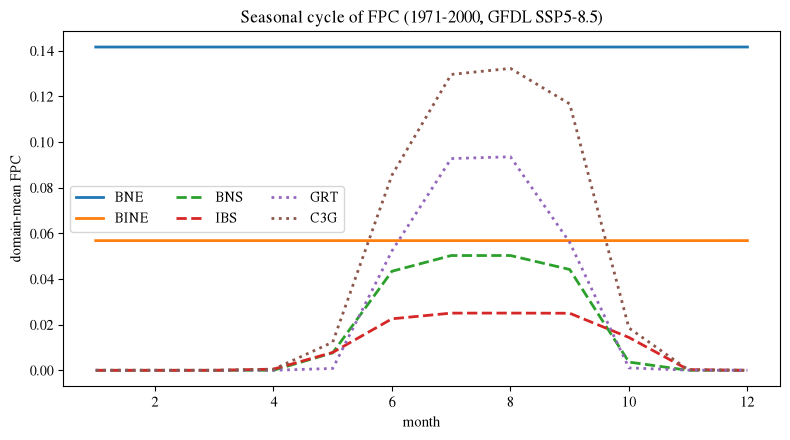

In [11]:
dom = fpc_fut.mean(("lat","lon"))       # domain-mean per PFT per month
fig, ax = plt.subplots(figsize=(8,4.5))
for p, style in [("BNE","-"),("BINE","-"),("BNS","--"),("IBS","--"),
                 ("GRT",":"),("C3G",":")]:
    ax.plot(dom.month, dom.sel(natpft=p), style, label=p, lw=2)
ax.set_xlabel("month"); ax.set_ylabel("domain-mean FPC"); ax.legend(ncol=3)
ax.set_title("Seasonal cycle of FPC (2070-2100, GFDL SSP5-8.5)")
plt.tight_layout()

dom = fpc_hist.mean(("lat","lon"))       # domain-mean per PFT per month
fig, ax = plt.subplots(figsize=(8,4.5))
for p, style in [("BNE","-"),("BINE","-"),("BNS","--"),("IBS","--"),
                 ("GRT",":"),("C3G",":")]:
    ax.plot(dom.month, dom.sel(natpft=p), style, label=p, lw=2)
ax.set_xlabel("month"); ax.set_ylabel("domain-mean FPC"); ax.legend(ncol=3)
ax.set_title("Seasonal cycle of FPC (1971-2000, GFDL SSP5-8.5)")
plt.tight_layout()


## 2 · Peak-month vs annual-mean: how big is the deciduous under-read?
For each PFT: annual mean vs annual max (peak month) of FPC, domain-averaged
over cells where it is present. The ratio mean/max ≈ 1 for evergreens, ≪ 1 for
deciduous — that gap is exactly the bias the peak approach removes.


In [14]:
fpc_mean = fpc_fut.mean("month")                 # annual-mean FPC
fpc_max  = fpc_fut.max("month")                  # annual-max (peak) FPC
rows = []
for p in LPJ_NATURAL:
    m = fpc_max.sel(natpft=p) > 0.01           # cells where present at peak
    mn = float(fpc_mean.sel(natpft=p).where(m).mean())
    mx = float(fpc_max.sel(natpft=p).where(m).mean())
    rows.append((p, mn, mx, mn/mx if mx > 0 else np.nan))
tab_fut = pd.DataFrame(rows, columns=["PFT","mean","max","mean/max"])
print("Future:")
print(tab_fut.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fpc_mean = fpc_hist.mean("month")                 # annual-mean FPC
fpc_max  = fpc_hist.max("month")                  # annual-max (peak) FPC
rows = []
for p in LPJ_NATURAL:
    m = fpc_max.sel(natpft=p) > 0.01           # cells where present at peak
    mn = float(fpc_mean.sel(natpft=p).where(m).mean())
    mx = float(fpc_max.sel(natpft=p).where(m).mean())
    rows.append((p, mn, mx, mn/mx if mx > 0 else np.nan))
tab_hist = pd.DataFrame(rows, columns=["PFT","mean","max","mean/max"])
print("Historical:")
print(tab_hist.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nmean/max near 1 = flat (evergreen); well below 1 = strong seasonality (deciduous)")


Future:
 PFT  mean   max  mean/max
 BNE 0.241 0.241     1.000
BINE 0.164 0.165     1.000
 BNS 0.184 0.483     0.380
TeNE 0.019 0.019     0.999
TeBE 0.015 0.015     0.997
 IBS 0.077 0.170     0.455
TeBS 0.067 0.124     0.538
 C3G 0.040 0.108     0.370
 HSE 0.074 0.074     1.000
 HSS 0.016 0.044     0.370
 LSE 0.021 0.021     1.000
 LSS 0.018 0.054     0.331
 GRT 0.046 0.149     0.306
EPDS 0.021 0.021     0.999
SPDS 0.005 0.018     0.265
 CLM   NaN   NaN       NaN
Historical:
 PFT  mean   max  mean/max
 BNE 0.340 0.340     1.000
BINE 0.137 0.137     1.000
 BNS 0.075 0.228     0.331
TeNE   NaN   NaN       NaN
TeBE   NaN   NaN       NaN
 IBS 0.047 0.116     0.403
TeBS 0.110 0.248     0.443
 C3G 0.063 0.203     0.311
 HSE 0.057 0.057     1.000
 HSS 0.010 0.028     0.362
 LSE 0.018 0.018     1.000
 LSS 0.007 0.024     0.308
 GRT 0.089 0.337     0.264
EPDS 0.018 0.018     0.999
SPDS 0.013 0.050     0.256
 CLM   NaN   NaN       NaN

mean/max near 1 = flat (evergreen); well below 1 = strong sea

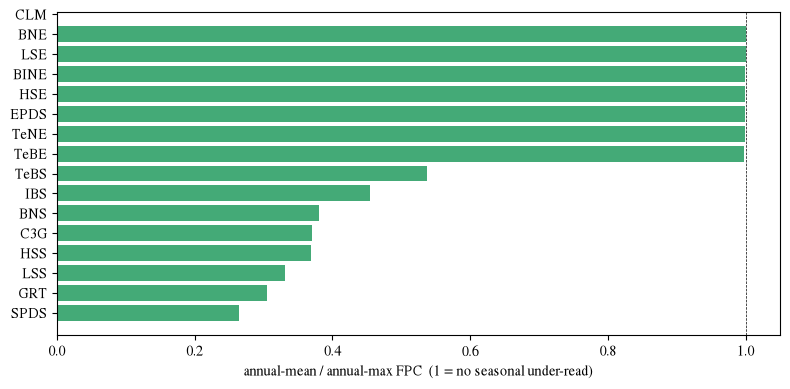

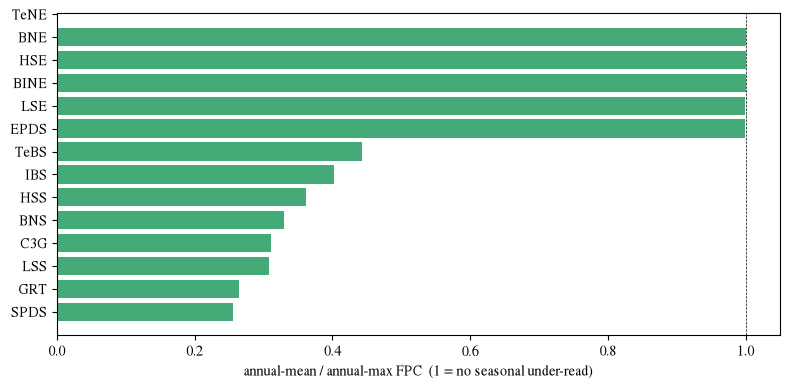

In [15]:
fig, ax = plt.subplots(figsize=(8,4))
tab_s = tab_fut.sort_values("mean/max")
ax.barh(tab_s["PFT"], tab_s["mean/max"], color="#4a7")
ax.axvline(1.0, color="k", lw=0.5, ls="--")
ax.set_xlabel("annual-mean / annual-max FPC  (1 = no seasonal under-read)")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8,4))
tab_s = tab_hist.sort_values("mean/max")
ax.barh(tab_s["PFT"], tab_s["mean/max"], color="#4a7")
ax.axvline(1.0, color="k", lw=0.5, ls="--")
ax.set_xlabel("annual-mean / annual-max FPC  (1 = no seasonal under-read)")
plt.tight_layout()


## 3 · Which month is the peak? (per PFT)
Confirms the annual-max is picking the growing season, and shows phenological
timing differences (e.g. larch vs evergreen).


In [6]:
peak_month = fpc_m.fillna(0).argmax("month") + 1        # 1-based month of max
for p in ["BNE","BNS","IBS","GRT","C3G","HSS"]:
    pm = peak_month.sel(natpft=p).where(fpc_max.sel(natpft=p) > 0.01)
    vals, counts = np.unique(pm.values[np.isfinite(pm.values)], return_counts=True)
    dominant = int(vals[np.argmax(counts)]) if len(vals) else -1
    print(f"  {p:5s}: most common peak month = {dominant}")


  BNE  : most common peak month = 12
  BNS  : most common peak month = 7
  IBS  : most common peak month = 7
  GRT  : most common peak month = 8
  C3G  : most common peak month = 8
  HSS  : most common peak month = 7
